<a href="https://colab.research.google.com/github/Abdulrashidkuti/Cyber-bulling-detection-using-RNN-LSTM/blob/main/Weapon_Detection_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Install necessary libraries (YOLOv8 + dependencies)
!pip install ultralytics opencv-python matplotlib

# Verify GPU (critical for speed)
import torch
print(f"GPU available: {torch.cuda.is_available()}")
print(f"GPU name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 29.6 MB/s eta 0:00:00
GPU available: True
GPU name: Tesla T4


In [3]:
import os
dataset_path = "/content/drive/MyDrive/Weapon_Detection 4"
print("Contents of your dataset folder:")
print(os.listdir(dataset_path))

Contents of your dataset folder:
['metadata.csv', 'test', 'train']


## Let check the structure of our Dataset

In [4]:
import os

def inspect_folder_structure(base_path):
    print(f"\nInspecting: {base_path}")
    for root, dirs, files in os.walk(base_path):
        level = root.replace(base_path, '').count(os.sep)
        indent = ' ' * 4 * level
        print(f"{indent}{os.path.basename(root)}/")
        subindent = ' ' * 4 * (level + 1)
        for f in files[:5]:  # Show first 5 files only
            print(f"{subindent}{f}")
        if len(files) > 5:
            print(f"{subindent}... and {len(files)-5} more")

dataset_path = "/content/drive/MyDrive/Weapon_Detection 4"
inspect_folder_structure(dataset_path)


Inspecting: /content/drive/MyDrive/Weapon_Detection 4
Weapon_Detection 4/
    metadata.csv
    test/
        test/
            army.jpg
            weapons.jpg
            weapons2.jpg
            terrorists.jpg
            terrorists2.jpg
    train/
        labels.cache
        val/
            labels.cache
            images/
                Automatic Rifle_40.jpeg
                Automatic Rifle_41.png
                Automatic Rifle_43.png
                Automatic Rifle_42.jpeg
                Automatic Rifle_35.jpeg
                ... and 135 more
            labels/
                Automatic Rifle_35.txt
                Automatic Rifle_42.txt
                Automatic Rifle_54.txt
                Automatic Rifle_77.txt
                Automatic Rifle_62.txt
                ... and 138 more
        labels/
            Automatic Rifle_12.txt
            Automatic Rifle_10.txt
            Automatic Rifle_11.txt
            Automatic Rifle_14.txt
            Automatic Rifle_100.tx

## Observation
#### Dataset Structure Summary
+ Test Set:

Path: /test/test/ (contains mixed images/GIFs, no visible labels)

Issue: Needs cleaning (GIFs may not work with YOLO)

+ Train/Val Set:

Properly organized with:

/train/images/ + /train/labels/ (YOLO format)

/train/val/images/ + /train/val/labels/ (YOLO format)

NOW WE ARE GOING TO CLEAN OUR THE TEST PART (CLEANING OUR DATASET)

In [5]:
import os

# Remove non-image files from test set
test_dir = "/content/drive/MyDrive/Weapon_Detection 4/test/test"
for file in os.listdir(test_dir):
    if not file.lower().endswith(('.jpg', '.jpeg', '.png')):
        os.remove(os.path.join(test_dir, file))
        print(f"Removed: {file}")

print(f"\nTest set now contains {len(os.listdir(test_dir))} valid images")


Test set now contains 5 valid images


### Verify YOLO Annotations


In [6]:
# Check a random train label
import random
label_path = "/content/drive/MyDrive/Weapon_Detection 4/train/labels"
sample_label = os.path.join(label_path, random.choice(os.listdir(label_path)))
with open(sample_label, 'r') as f:
    print("Sample YOLO label content:\n", f.read())

Sample YOLO label content:
 0 0.510718 0.538579 0.956002 0.504569



### Create YOLO Dataset Config
+ Make a data.yaml file:

In [7]:
import yaml

data = {
    'train': '/content/drive/MyDrive/Weapon_Detection 4/train/images',
    'val': '/content/drive/MyDrive/Weapon_Detection 4/train/val/images',
    'test': '/content/drive/MyDrive/Weapon_Detection 4/test/test',
    'names': ['Automatic Rifle'],
    'nc': 1  # Number of classes
}

with open('data.yaml', 'w') as f:
    yaml.dump(data, f)

print("Created data.yaml:\n", open('data.yaml').read())

Created data.yaml:
 names:
- Automatic Rifle
nc: 1
test: /content/drive/MyDrive/Weapon_Detection 4/test/test
train: /content/drive/MyDrive/Weapon_Detection 4/train/images
val: /content/drive/MyDrive/Weapon_Detection 4/train/val/images



# LET START TRAINING

In [8]:
from ultralytics import YOLO

# Load pretrained model
model = YOLO("yolov8n.pt")  # or "yolov8s.pt" for smaller model

# Train (adjust epochs as needed)
results = model.train(
    data="data.yaml",
    epochs=50,
    imgsz=640,
    batch=16
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.201 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, lin

## Observation of my result after training

#### Key Metrics
+ Metric	Value	Interpretation
+ Precision	0.905	90.5% of detected weapons were correct (low false positives)
+ Recall	0.844	84.4% of actual weapons were detected (some false negatives)
+ mAP50	0.928	92.8% mean average precision at IoU=50% (excellent for weapon detection)
+ mAP50-95	0.717	71.7% mAP at varying IoU thresholds (good for real-world use)

In [9]:
!pip install ultralytics opencv-python

## Uploading the Video that i will use for test from my file

In [10]:
from google.colab import files
uploaded = files.upload()

Saving WEAPON.mp4 to WEAPON.mp4


In [11]:
!ls # Checking if the video is truly uploaded

data.yaml  drive  runs	sample_data  WEAPON.mp4  yolo11n.pt  yolov8n.pt


In [12]:
import cv2

# Checking if video is readable
video_path = "WEAPON.mp4"
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("❌ Error: Could not open video. Possible issues:")
    print("- Corrupt file")
    print("- Wrong codecs (try re-encoding with FFmpeg)")
else:
    print(f"✅ Video loaded successfully! Details:")
    print(f"- Frames: {int(cap.get(cv2.CAP_PROP_FRAME_COUNT))}")
    print(f"- Resolution: {int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))}x{int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))}")
    cap.release()

✅ Video loaded successfully! Details:
- Frames: 166
- Resolution: 640x280


In [13]:
from ultralytics import YOLO

model = YOLO("runs/detect/train/weights/best.pt")  # Your trained model
model.predict(
    source="WEAPON.mp4",
    conf=0.6,     # Confidence threshold
    save=True,    # Saves to runs/detect/predict/
    show=False    # Disables unsupported cv2.imshow()
)

# Workaround to display results in Colab
from IPython.display import Video
Video("runs/detect/predict/WEAPON.mp4", embed=True)


WARNING ⚠️ 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/166) /content/WEAPON.mp4: 288x640 1 Automatic Rifle, 37.3ms
video 1/1 (frame 2/166) /content/WEAPON.mp4: 288x640 1 Automatic Rifle, 39.0ms
video 1/1 (frame 3/166) /content/WEAPON.mp4: 288x640 1 Automatic Rifle, 8.5ms
video 1/1 (frame 4/166) /content/WEAPON.mp4: 288x640 1 Automatic Rifle, 5.9ms
video 1/1 (frame 5/166) /content/WEAPON.mp4: 288x640 1 Automatic Rifle, 5.9ms
video 1/1 (frame 6/166) /content/WEAPON.mp4: 288x640 1 Automatic

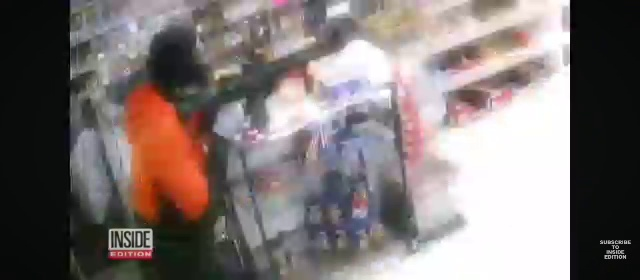

Frame 129/166 saved as 'test_frame.jpg'


In [14]:
import cv2
import random
from IPython.display import Image, display

# Open the video
cap = cv2.VideoCapture("WEAPON.mp4")
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Pick and show a random frame
random_frame = random.randint(0, total_frames-1)
cap.set(cv2.CAP_PROP_POS_FRAMES, random_frame)
ret, frame = cap.read()
cap.release()

if ret:
    cv2.imwrite("test_frame.jpg", frame)
    display(Image("test_frame.jpg"))  # Show the frame
    print(f"Frame {random_frame}/{total_frames} saved as 'test_frame.jpg'")
else:
    print("❌ Error: Could not read frame.")


image 1/1 /content/test_frame.jpg: 288x640 (no detections), 8.5ms
Speed: 0.9ms preprocess, 8.5ms inference, 0.8ms postprocess per image at shape (1, 3, 288, 640)


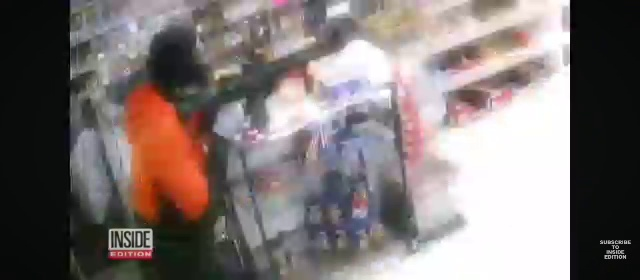

Detected objects: []


In [18]:
# @title Default title text
from ultralytics import YOLO

# Load model and predict
model = YOLO("runs/detect/train/weights/best.pt")
results = model.predict("test_frame.jpg", conf=0.3)  # Low confidence threshold
results[0].show()  # Show results (boxes/labels)
print("Detected objects:", results[0].boxes.cls.tolist())  # Class IDs

Processing: weapons2.jpg


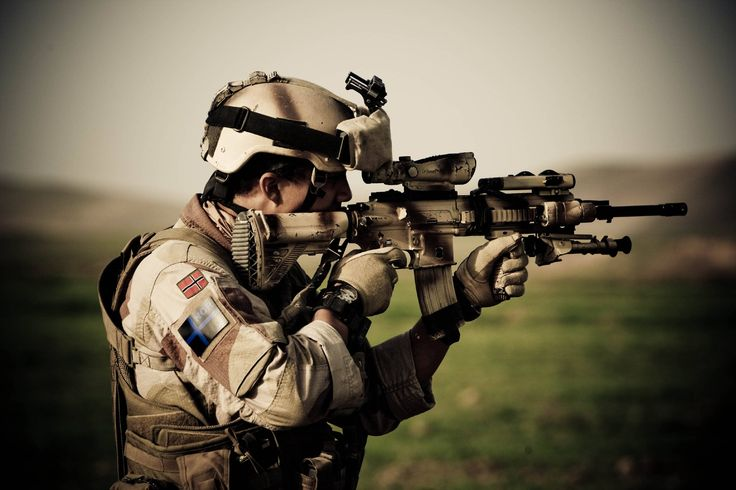

FileNotFoundError: No such file or directory: 'runs/detect/predict/weapons2.jpg'

FileNotFoundError: No such file or directory: 'runs/detect/predict/weapons2.jpg'

<IPython.core.display.Image object>

Weapons detected: 1


In [16]:
from ultralytics import YOLO
import os
from IPython.display import display, Image, clear_output

# 1. SET YOUR TEST FOLDER PATH
test_folder = "/content/drive/MyDrive/Weapon_Detection 4/test/test"  # 👈 CHANGE THIS to your folder path

# 2. LOAD MODEL
model = YOLO("runs/detect/train/weights/best.pt")  # Your trained model

# 3. RUN DETECTION ON ALL IMAGES
for img_file in sorted(os.listdir(test_folder)):
    if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
        img_path = os.path.join(test_folder, img_file)

        # Detect and save results
        results = model.predict(img_path, conf=0.4, save=True)

        # Display results
        clear_output(wait=True)  # Cleaner output
        print(f"Processing: {img_file}")
        display(Image(img_path))  # Original
        display(Image(f"runs/detect/predict/{img_file}"))  # Result
        print(f"Weapons detected: {len(results[0].boxes)}\n{'='*50}")

In [17]:
from ultralytics import YOLO
from google.colab import files
import os
from IPython.display import display, Image
import shutil

# 1. UPLOAD UNZIPPED FOLDER (MULTI-SELECT)
print("Please select ALL images from your test folder:")
uploaded = files.upload()  # Manually select all images (Ctrl/Cmd + Click)
!mkdir -p test_images  # Create folder
for filename in uploaded.keys():
    shutil.move(filename, f"test_images/{filename}")  # Organize files

# 2. LOAD MODEL
model = YOLO("runs/detect/train/weights/best.pt")

# 3. PROCESS AND DISPLAY
for img_file in sorted(os.listdir("test_images")):
    if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
        img_path = f"test_images/{img_file}"

        # Run detection
        results = model.predict(img_path, conf=0.3, save=True)

        # Display results
        print(f"\n🔍 {img_file}:")
        display(Image(img_path))  # Original
        display(Image(f"runs/detect/predict/{img_file}"))  # Processed
        print(f"Detected weapons: {len(results[0].boxes)}")

# 4. DOWNLOAD RESULTS
!zip -r results.zip runs/detect/predict
files.download("results.zip")  # Optional download

Please select ALL images from your test folder:


Saving WEAPON.mp4 to WEAPON (1).mp4
  adding: runs/detect/predict/ (stored 0%)
  adding: runs/detect/predict/WEAPON.avi (deflated 1%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>